In [119]:
import torch
import torch.nn.functional as F
import imageio
import numpy as np
import cv2

In [120]:
import os
import torch
import sys
import matplotlib.pyplot as plt
from gsplat import rasterization
from optical.surface import WaterSurface
from optical.utils.test_utils import LoadDataset
from optical.utils.test_utils import combert_into_colormap, compare_rasterization_variants, colormap_ray_angle_and_ratio

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

Dataset = LoadDataset()
Dataset.set_iamge(80)
# envmap_path = "hdr_040_field_prev.jpg"
envmap_path = 'qwantani_dusk_2_2k.exr'
# envmap_path = 'rainforest_trail_2k.exr'

means, scales, quats, opacities, colors = Dataset.get_model_param()
pixels_wo, pixels_w, camtoworld, worldtocam, cam_center, K, height, width, image_id = Dataset.get_camera_param()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.
Loading 3D point cloud from: /home/taiki/dataset/river2/refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/refraction.


In [121]:
WS = WaterSurface(
    means=means,
    scales=scales,
    quats=quats,
    opacities=opacities,
    device=device,
    
    camtoworld=camtoworld[0],
    K=K[0],
    width=width,
    height=height,
)

t_means, t_quats = WS.transform_to_appearance()
t_scales = WS.scale_correction_as_real(comp_by="edges")
map_colors = combert_into_colormap(WS.scale_correction_factor_by_edges, colormap='plasma')

rays_WS = WS.calc_ray_of_each_pixel()
WS.load_environment_map(envmap_path=envmap_path)


In [122]:
env_colors = WS.get_colors_from_envmap(rays_WS)

_ = WS.schlick_fresnel_reflectance()

cos_theta_i:
 tensor([[0.0508, 0.0508, 0.0509,  ..., 0.0509, 0.0509, 0.0508],
        [0.0518, 0.0518, 0.0519,  ..., 0.0519, 0.0519, 0.0518],
        [0.0528, 0.0528, 0.0528,  ..., 0.0529, 0.0528, 0.0528],
        ...,
        [0.8041, 0.8048, 0.8055,  ..., 0.8062, 0.8055, 0.8048],
        [0.8043, 0.8050, 0.8057,  ..., 0.8064, 0.8057, 0.8050],
        [0.8046, 0.8053, 0.8060,  ..., 0.8067, 0.8060, 0.8053]],
       device='cuda:0')


In [123]:
i = WS.cos_theta_air

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.9326483..1.8917204].


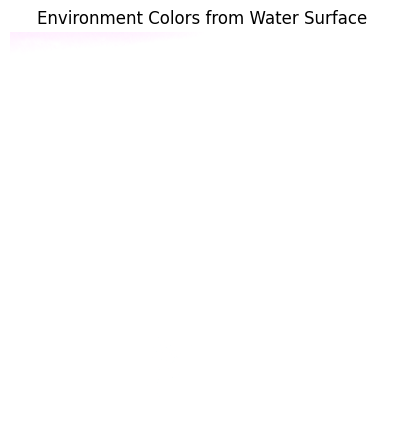

In [124]:
# refrected rays and get env map colors
reflected_rays = WS.calc_refrected_ray()
refrected_env_colors = WS.get_colors_from_envmap(reflected_rays)

refrected_env_colors_np = refrected_env_colors.cpu().numpy()
render_rgb = refrected_env_colors_np[:,:,:3]

# if the environment map has alpha channel
if refrected_env_colors_np.shape[2] == 4:
    a = refrected_env_colors_np[:,:,3].clip(0, 1)    

plt.figure(figsize=(10, 5))
plt.imshow(render_rgb, alpha=a if 'a' in locals() else None)
plt.axis('off')
plt.title('Environment Colors from Water Surface')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3444768].


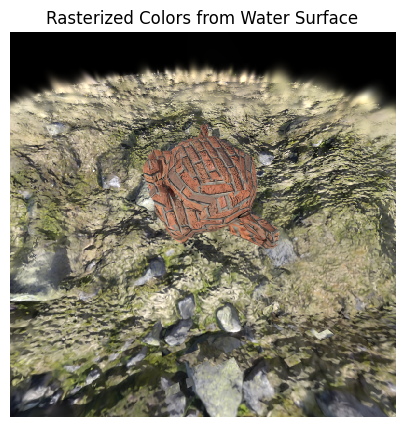

In [125]:
render_rgb, render_alpha, _ = rasterization(
    means=t_means,
    scales=t_scales,
    quats=t_quats,
    opacities=opacities,
    colors=colors,
    viewmats=worldtocam[0].unsqueeze(0),
    Ks=K[0].unsqueeze(0),
    width=width,
    height=height,
    sh_degree=0
)
# render_rgb shape, (1, height, width, 3) [0,1]の範囲のRGB値

img = render_rgb.squeeze().detach().cpu().numpy() # (height, width, 3) 長さ1の次元を消去 (dimを指定しなければすべて消去する)

plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')
plt.title('Rasterized Colors from Water Surface')
plt.show()


In [126]:
spec_ratio, spec, trans = WS.schlick_fresnel_reflectance()
print(f"spec_ratio : {spec_ratio}") # (height, width
# trans: (height, width, 1) 透過率
# spec: (height, width, 1) 反射率

env_rgb = refrected_env_colors         # (height, width, 3)

cos_theta_i:
 tensor([[0.0508, 0.0508, 0.0509,  ..., 0.0509, 0.0509, 0.0508],
        [0.0518, 0.0518, 0.0519,  ..., 0.0519, 0.0519, 0.0518],
        [0.0528, 0.0528, 0.0528,  ..., 0.0529, 0.0528, 0.0528],
        ...,
        [0.8041, 0.8048, 0.8055,  ..., 0.8062, 0.8055, 0.8048],
        [0.8043, 0.8050, 0.8057,  ..., 0.8064, 0.8057, 0.8050],
        [0.8046, 0.8053, 0.8060,  ..., 0.8067, 0.8060, 0.8053]],
       device='cuda:0')
spec_ratio : 0.020059317350387573


In [127]:

reflected_img = trans * render_rgb * render_alpha\
    +  spec * env_rgb

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.036858782..1.308831].


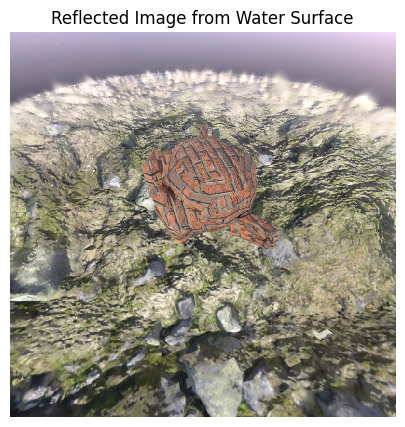

In [128]:
# show
plt.figure(figsize=(10, 5))
plt.imshow(reflected_img.squeeze().detach().cpu().numpy())
plt.axis('off')
plt.title('Reflected Image from Water Surface')
plt.show()


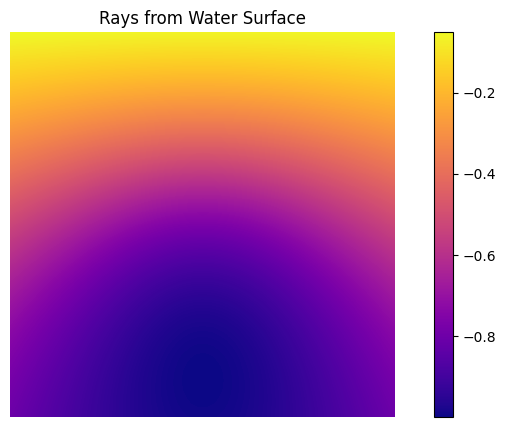

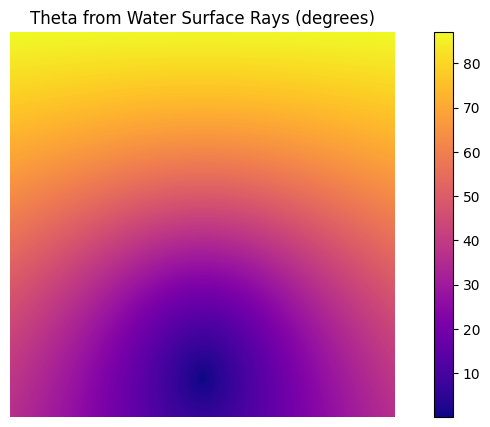

In [129]:
rays = WS.rays

# show rays as color map 
rays_np = rays.cpu().numpy()
plt.figure(figsize=(10, 5))
plt.imshow(rays_np[:, :, 2])
plt.axis('off')
plt.title('Rays from Water Surface')
plt.set_cmap('plasma')
plt.colorbar()
plt.show()

theta = np.arccos(-rays_np[:, :, 2]) * 180 / np.pi
plt.figure(figsize=(10, 5))
plt.imshow(theta, cmap='plasma')
plt.axis('off')
plt.title('Theta from Water Surface Rays (degrees)')
plt.colorbar()
plt.show()


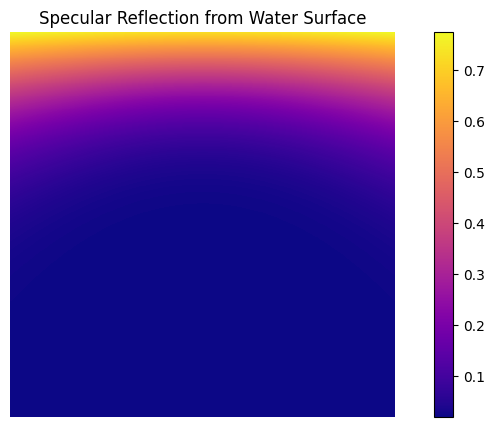

In [130]:
# show spec as
plt.figure(figsize=(10, 5))
plt.imshow(spec.squeeze().detach().cpu().numpy(), cmap='plasma')
plt.axis('off')
plt.title('Specular Reflection from Water Surface')
plt.colorbar()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.042660873..1.3132674].


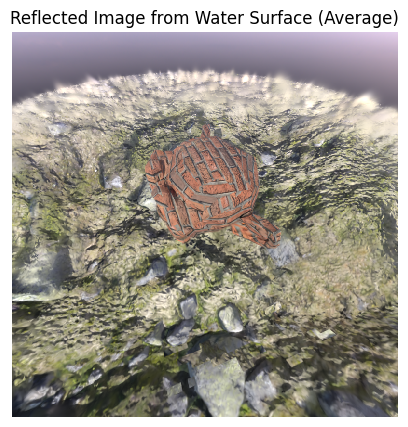

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.036858782..1.308831].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.042660873..1.3132674].


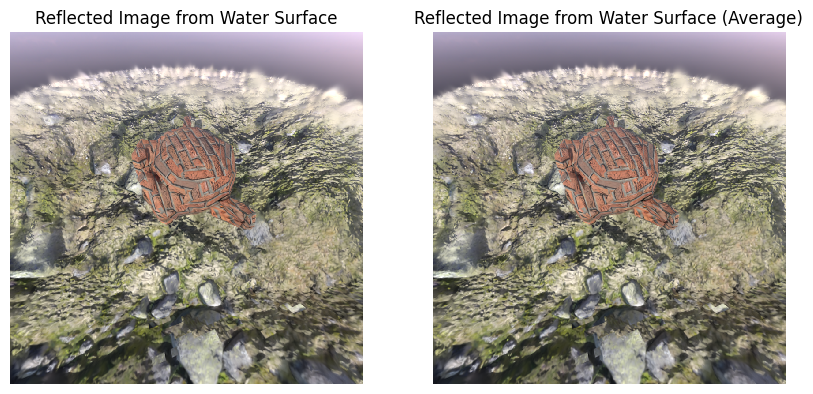

In [131]:
spec_ave, trans_ave = WS.fresnel_reflectance()

reflected_img_ave = trans_ave * render_rgb * render_alpha\
    +  spec_ave * env_rgb
    
# show
plt.figure(figsize=(10, 5))
plt.imshow(reflected_img_ave.squeeze().detach().cpu().numpy())
plt.axis('off')
plt.title('Reflected Image from Water Surface (Average)')
plt.show()

# compare two images 
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(reflected_img.squeeze().detach().cpu().numpy())
plt.axis('off')
plt.title('Reflected Image from Water Surface')
plt.subplot(1, 2, 2)
plt.imshow(reflected_img_ave.squeeze().detach().cpu().numpy())
plt.axis('off')
plt.title('Reflected Image from Water Surface (Average)')
plt.show()



In [132]:
def Fr(theta_i, n_i=1.33, n_t=1.0):
    # sin(theta_t) = (n_i / n_t) * sin(theta_i)
    sin_theta_t = n_i / n_t * np.sin(theta_i)
    # clip to [-1, +1] to avoid invalid values in arcsin
    sin_theta_t = np.clip(sin_theta_t, -1.0, 1.0)
    theta_t = np.arcsin(sin_theta_t)

    # Fresnel for horizontal/parallel polarization
    rs = (n_t * np.cos(theta_i) - n_i * np.cos(theta_t)) / \
            (n_t * np.cos(theta_i) + n_i * np.cos(theta_t))
    # Fresnel for vertical/perpendicular polarization
    rp = (n_i * np.cos(theta_i) - n_t * np.cos(theta_t)) / \
            (n_i * np.cos(theta_i) + n_t * np.cos(theta_t))

    # average the two
    R = (rs**2 + rp**2) / 2.0

    # total internal reflection where k > 1
    return np.where(sin_theta_t >= 1.0, 1.0, R)

Fr(np.radians(0))



array(0.02005931)

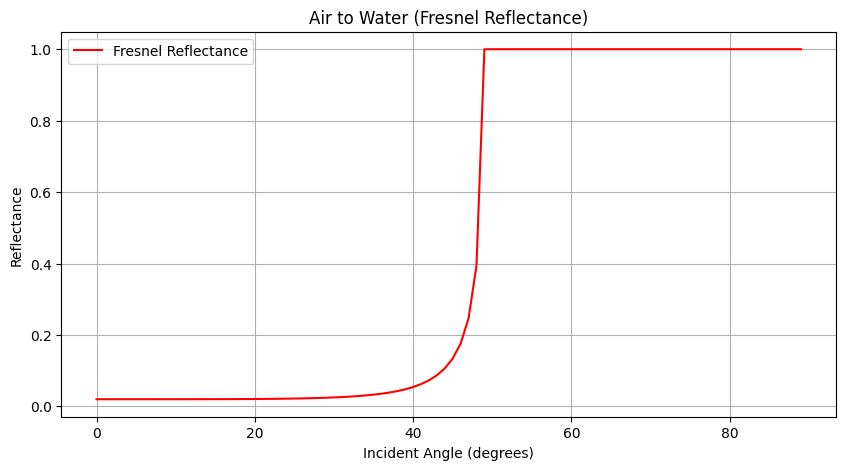

In [133]:
# plot
theta_i = np.arange(0, 90, 1)
incident_angle_rad = np.radians(theta_i)
reflectance = Fr(incident_angle_rad)
plt.figure(figsize=(10, 5))
plt.plot(theta_i, reflectance, label='Fresnel Reflectance', color='red')
plt.xlabel('Incident Angle (degrees)')
plt.ylabel('Reflectance')
plt.title('Air to Water (Fresnel Reflectance)')
plt.grid()
plt.legend()
plt.show()

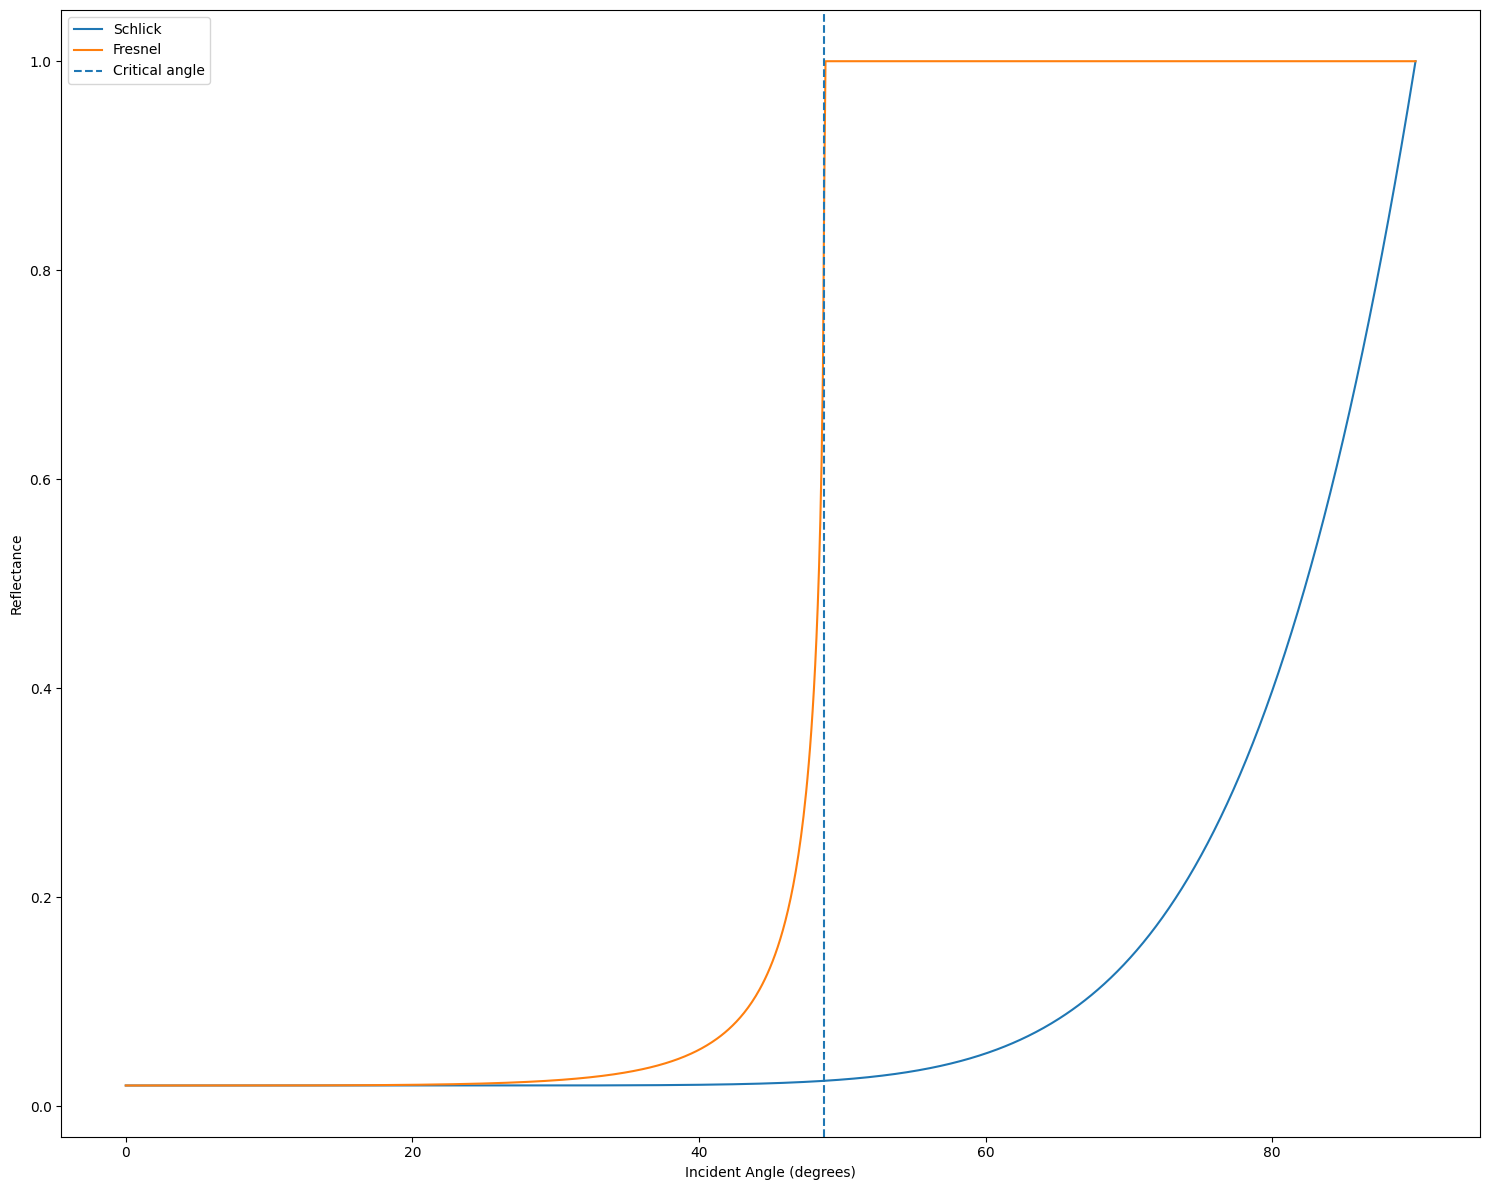

In [134]:
import numpy as np
import matplotlib.pyplot as plt

# Improved resolution: 1000 points from 0 to 90 degrees
incident_angle = np.linspace(0, np.pi/2, 1000)

def schlick(theta_i, n_i=1.33, n_t=1.0):
    # Schlick's approximation
    r0 = ((n_i - n_t) / (n_i + n_t)) ** 2
    return r0 + (1 - r0) * (1 - np.cos(theta_i))**5

def fresnel(theta_i, n_i=1.33, n_t=1.0):
    # Full Fresnel equations for unpolarized light
    sin_theta_t = np.sin(theta_i) * n_i / n_t
    cos_theta_i = np.cos(theta_i)
    cos_theta_t = np.sqrt(np.clip(1 - sin_theta_t**2, 0, 1))
    rs = ((n_t*cos_theta_i - n_i*cos_theta_t)/(n_t*cos_theta_i + n_i*cos_theta_t))**2
    rp = ((n_i*cos_theta_i - n_t*cos_theta_t)/(n_i*cos_theta_i + n_t*cos_theta_t))**2
    reflectance = (rs + rp) / 2
    # Handle total internal reflection
    return np.where(sin_theta_t <= 1, reflectance, 1.0)

# Compute reflectance curves
schlick_r = schlick(incident_angle)
fresnel_r = fresnel(incident_angle)
critical_angle = np.degrees(np.arcsin(1.0/1.33))

# Plot
plt.figure()
plt.plot(np.degrees(incident_angle), schlick_r, label="Schlick")
plt.plot(np.degrees(incident_angle), fresnel_r, label="Fresnel")
plt.axvline(critical_angle, linestyle="--", label="Critical angle")
plt.xlabel("Incident Angle (degrees)")
plt.ylabel("Reflectance")
plt.legend()
plt.tight_layout()
plt.show()


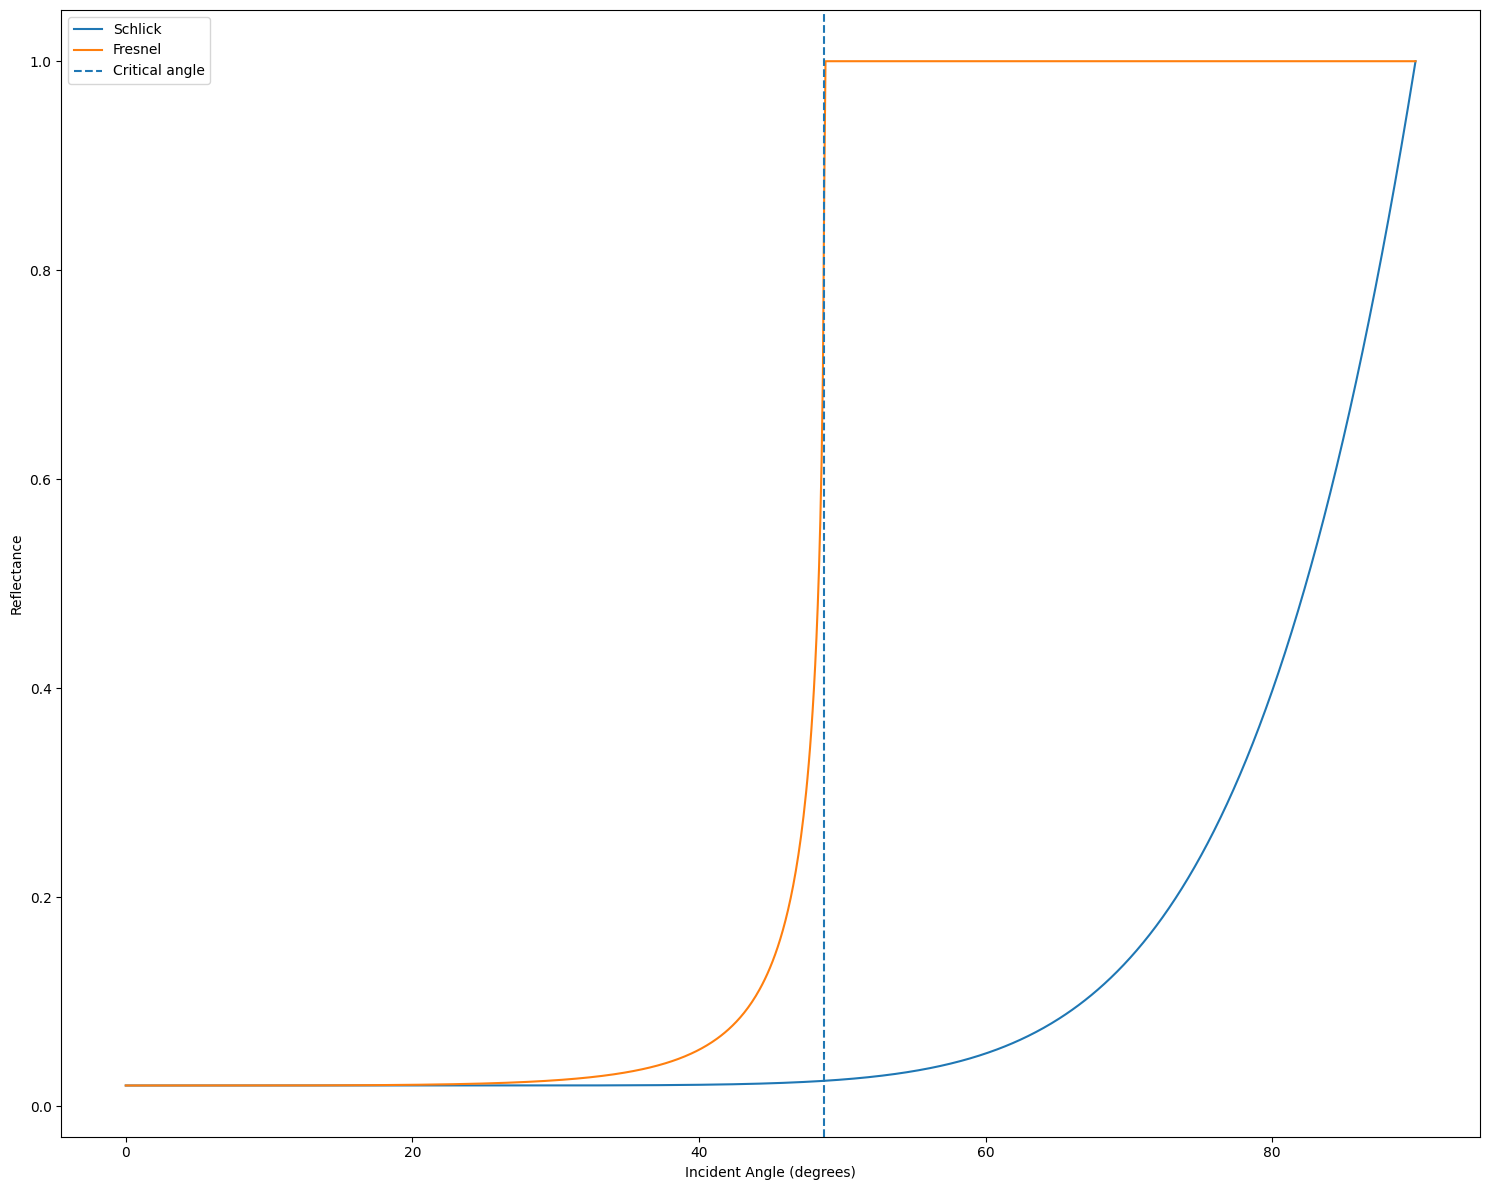

In [135]:
import numpy as np
import matplotlib.pyplot as plt

# Improved resolution: 1000 points from 0 to 90 degrees
incident_angle = np.linspace(0, np.pi/2, 1000)

def schlick(theta_i, n_i=1.33, n_t=1.0):
    # Schlick's approximation
    r0 = ((n_i - n_t) / (n_i + n_t)) ** 2
    return r0 + (1 - r0) * (1 - np.cos(theta_i))**5

def fresnel(theta_i, n_i=1.33, n_t=1.0):
    # Full Fresnel equations for unpolarized light
    sin_theta_t = np.sin(theta_i) * n_i / n_t
    cos_theta_i = np.cos(theta_i)
    cos_theta_t = np.sqrt(np.clip(1 - sin_theta_t**2, 0, 1))
    rs = ((n_t*cos_theta_i - n_i*cos_theta_t)/(n_t*cos_theta_i + n_i*cos_theta_t))**2
    rp = ((n_i*cos_theta_i - n_t*cos_theta_t)/(n_i*cos_theta_i + n_t*cos_theta_t))**2
    reflectance = (rs + rp) / 2
    # Handle total internal reflection
    return np.where(sin_theta_t <= 1, reflectance, 1.0)

# Compute reflectance curves
schlick_r = schlick(incident_angle)
fresnel_r = fresnel(incident_angle)
critical_angle = np.degrees(np.arcsin(1.0/1.33))

# Plot
plt.figure()
plt.plot(np.degrees(incident_angle), schlick_r, label="Schlick")
plt.plot(np.degrees(incident_angle), fresnel_r, label="Fresnel")
plt.axvline(critical_angle, linestyle="--", label="Critical angle")
plt.xlabel("Incident Angle (degrees)")
plt.ylabel("Reflectance")
plt.legend()
plt.tight_layout()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.042441577..1.0485077].


Text(0.5, 1.0, 'Reflected Image from Water Surface')

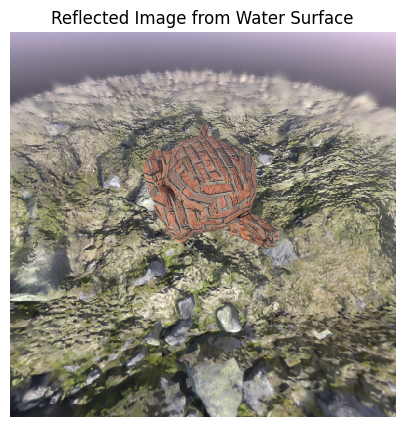

In [136]:
spec_w2a, trans_w2a = WS.fresnel_water2air()
spec_a2w, trans_a2w = WS.fresnel_air2water()

# ref_img = trans_w2a * render_rgb * render_alpha \
#         + spec_w2a * env_rgb
        
ref_img = trans_a2w * trans_w2a * render_rgb * render_alpha \
        + spec_w2a * env_rgb

# compare two images 
plt.figure(figsize=(10, 5))
plt.imshow(ref_img.squeeze().detach().cpu().numpy())
plt.axis('off')
plt.title('Reflected Image from Water Surface')


不自然だが、残りの色は本来はscattering なのかしれないい
あとは、環境マップはIntensityとしてもっとはばを広げて表示する要要があるかも

GS Render画像はすでに見かけのにに補正されれており、中中からの入射角が大くく見積もられてるる。よって、もとのRayを推定して、それを基に、光を減衰させてやる必要がるる。

必要以上に見えなくなってままっている

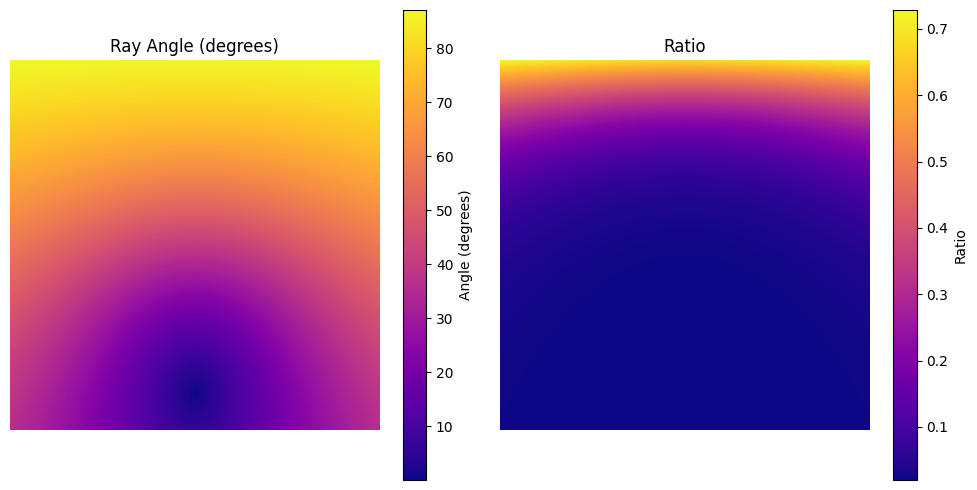

In [137]:
colormap_ray_angle_and_ratio(rays, spec_w2a)